# Investigate the number of observed events

In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "browser" 

import altair as alt
from itertools import combinations
import numpy as np
import math
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

import random
import plotly.graph_objects as go
import plotly.express as px

import scipy.cluster.hierarchy as sch
from collections import defaultdict, deque, Counter
from Bio import Phylo

from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, cluster_by_tree, strip_newick_suffixes, write_shared_nodes_fasta, simplify_cluster_keys, count_trna_per_junction, get_core_alignment_lengths, core_block_snp_gaps, add_silhouette_scores
from junction_analysis.junction_trees import build_tree_from_block_list, compute_pairwise_distances, cluster_tree_by_branch_length
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_junction_pangraph_interactive, plot_block_distance_distribution, plot_pairwise_distance_hist, plot_event_counts_distribution, plot_events_per_junction, plot_cluster_count_distribution, plot_event_length_distribution, plot_cluster_count_vs_diversity, plot_marginal_scatter, plot_clustering_threshold_sweep
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths, consensus_paths_and_assignments, find_consensus_paths_core, cluster_map_to_dataframe, collect_all_pairwise_distances, save_consensus_cache, collect_all_branch_lengths, fitch_parsimony_steps_per_cluster
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries, summarize_inversions_consensus, summarize_translocations_consensus, write_insertions_fasta, load_all_insertions_summaries, load_all_inversions_summaries, load_all_translocations_summaries, combine_all_junctions_summaries, count_events_per_junction, deduplicate_events

In [2]:
base_path = Path("../results/atb_lookup")

_fname = f"../config/junction_stats.csv"
jdf = pd.read_csv(_fname)
jdf

# summarize results
cluster_df = pd.read_csv("../results/consensus_analysis/cluster_maps_0_005.csv")
trna_counts_df = count_trna_per_junction(annotations_dir="../results/junction_annotations",
    category_bins=[-1, 0, 50, 300, float("inf")], category_labels=["0", "1–50", "50–300", ">300"],)
summaries = combine_all_junctions_summaries(str(base_path), save_df=True)
deduplicated_events_df = deduplicate_events(summaries, save_path=f"{base_path}/deduplicated_events.csv")  
counts_df = count_events_per_junction(deduplicated_events_df, min_length=200, save_path=f"{base_path}/event_counts_per_junction.csv")
#ji_df = pd.read_csv("../results/consensus_analysis/mean_diversity_per_junction.csv") 

jdf_trna = jdf.copy().merge(trna_counts_df.set_index("junction_name"), left_on="edge", right_index=True, how="left")                                 
jdf_clusters = jdf_trna.merge(cluster_df[["junction_name", "n_clusters"]].set_index("junction_name"), left_on="edge", right_index=True, how="left")

jdf_all = jdf_clusters.merge(counts_df.set_index("junction_name"), left_on="edge", right_index=True, how="left")                                                                                                                              
jdf_all[counts_df.columns.drop("junction_name")] = jdf_all[counts_df.columns.drop("junction_name")].fillna(0)

#jdf_all = jdf_all.merge(ji_df.set_index("junction_name"), left_on="edge", right_index = True, how="left")  

jdf_all.rename(columns={"edge": "junction_name"}, inplace=True)

# only continue with junctions that have at least 2 different paths, otherwise they are not junctions (could happen because of duplications to elsewhere or syntheny breaks) 
jdf_all = jdf_all[jdf_all["n_categories"] >= 2]
# for now don't filter out junctions with only very few isolates, but might generally make sense to do so

jdf_hotspot = jdf_all[jdf_all["n_categories"] > 2]
jdf_nonsingleton = jdf_all[jdf_all["singleton"] == False]
jdf_binary = jdf_all[jdf_all["n_categories"] == 2]
jdf_singleton = jdf_binary[jdf_binary["singleton"] == True]
jdf_binary_nonsingleton = jdf_binary[jdf_binary["singleton"] == False]

nonbinary_junctions = jdf_all[jdf_all['n_categories'] > 2].junction_name.tolist()                                                                                                                                                                                                                                                                               
summary_df_nb = deduplicated_events_df[deduplicated_events_df['junction_name'].isin(nonbinary_junctions)]

Saved insertions summary to ../results/atb_lookup/insertions/all_junctions_insertions.csv
Saved deletions summary to ../results/atb_lookup/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup/deduplicated_events.csv
Saved event counts to ../results/atb_lookup/event_counts_per_junction.csv


/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2078: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



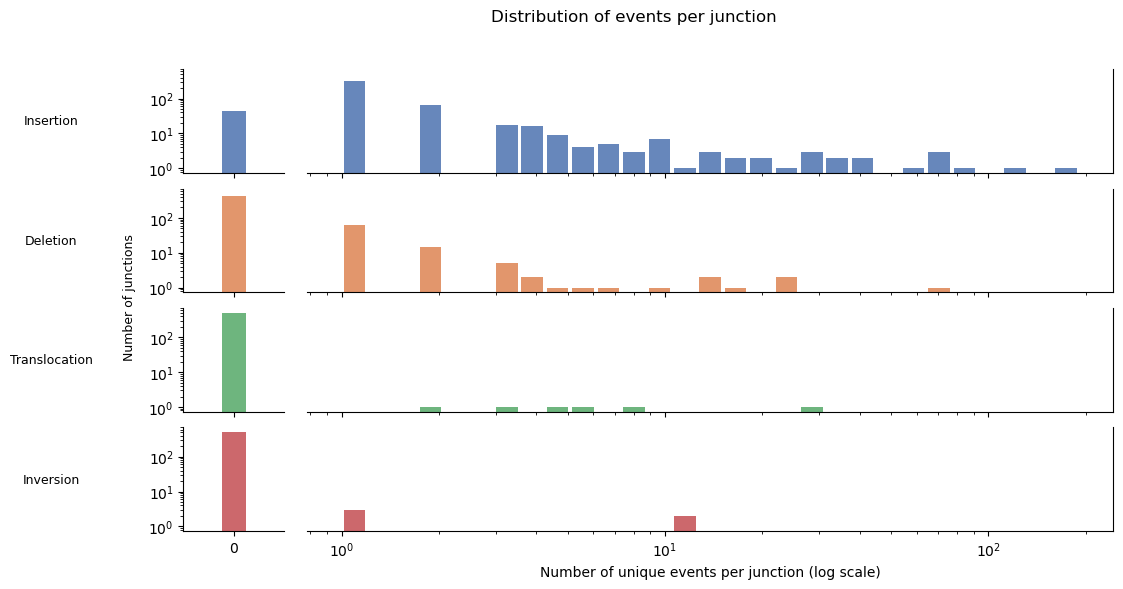

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2078: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



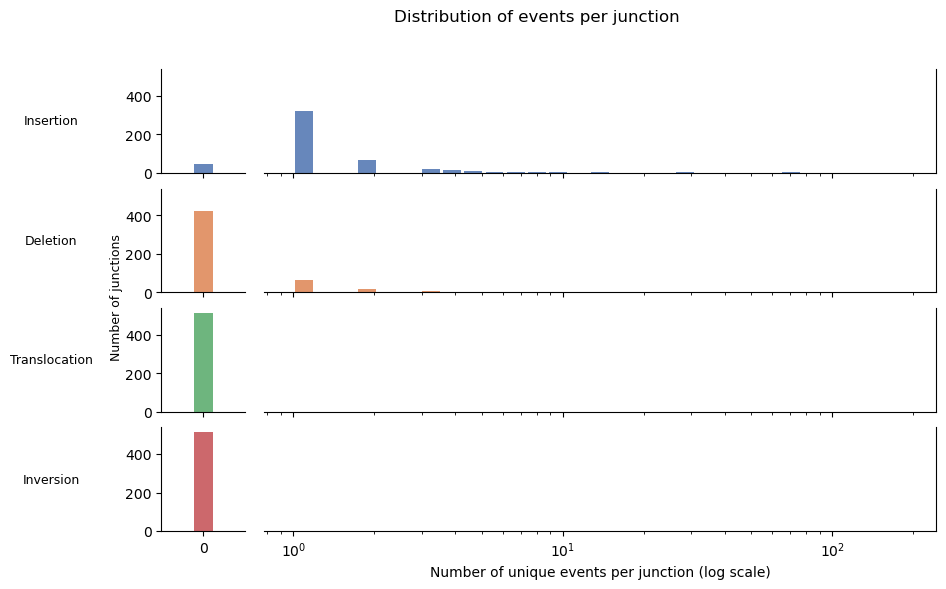

In [3]:
plot_event_counts_distribution(jdf_all, figsize=(12, 6), log_x = True, log_y = True, subplots = True)
plot_event_counts_distribution(jdf_all, figsize=(10, 6), log_x = True, log_y = False, subplots = True)

In [9]:
jdf_all[['n_insertion', 'n_deletion', 'n_translocation', 'n_inversion', 'n_events']].sum()

n_insertion        1802.0
n_deletion          305.0
n_translocation      51.0
n_inversion          26.0
n_events           2184.0
dtype: float64

In [15]:
base_path = Path("../results/atb_lookup_0001")

_fname = f"../config/junction_stats.csv"
jdf = pd.read_csv(_fname)
jdf

# summarize results
cluster_df = pd.read_csv("../results/consensus_analysis/cluster_maps_0_001.csv")
trna_counts_df = count_trna_per_junction(annotations_dir="../results/junction_annotations",
    category_bins=[-1, 0, 50, 300, float("inf")], category_labels=["0", "1–50", "50–300", ">300"],)
summaries = combine_all_junctions_summaries(str(base_path), save_df=True)
deduplicated_events_df = deduplicate_events(summaries, save_path=f"{base_path}/deduplicated_events.csv")  
counts_df = count_events_per_junction(deduplicated_events_df, min_length=200, save_path=f"{base_path}/event_counts_per_junction.csv")
#ji_df = pd.read_csv("../results/consensus_analysis/mean_diversity_per_junction.csv") 

jdf_trna = jdf.copy().merge(trna_counts_df.set_index("junction_name"), left_on="edge", right_index=True, how="left")                                 
jdf_clusters = jdf_trna.merge(cluster_df[["junction_name", "n_clusters"]].set_index("junction_name"), left_on="edge", right_index=True, how="left")

jdf_all = jdf_clusters.merge(counts_df.set_index("junction_name"), left_on="edge", right_index=True, how="left")                                                                                                                              
jdf_all[counts_df.columns.drop("junction_name")] = jdf_all[counts_df.columns.drop("junction_name")].fillna(0)

#jdf_all = jdf_all.merge(ji_df.set_index("junction_name"), left_on="edge", right_index = True, how="left")  

jdf_all.rename(columns={"edge": "junction_name"}, inplace=True)

# only continue with junctions that have at least 2 different paths, otherwise they are not junctions (could happen because of duplications to elsewhere or syntheny breaks) 
jdf_all = jdf_all[jdf_all["n_categories"] >= 2]
# for now don't filter out junctions with only very few isolates, but might generally make sense to do so

jdf_hotspot = jdf_all[jdf_all["n_categories"] > 2]
jdf_nonsingleton = jdf_all[jdf_all["singleton"] == False]
jdf_binary = jdf_all[jdf_all["n_categories"] == 2]
jdf_singleton = jdf_binary[jdf_binary["singleton"] == True]
jdf_binary_nonsingleton = jdf_binary[jdf_binary["singleton"] == False]

nonbinary_junctions = jdf_all[jdf_all['n_categories'] > 2].junction_name.tolist()                                                                                                                                                                                                                                                                               
summary_df_nb = deduplicated_events_df[deduplicated_events_df['junction_name'].isin(nonbinary_junctions)]

Saved insertions summary to ../results/atb_lookup_0001/insertions/all_junctions_insertions.csv
Saved deletions summary to ../results/atb_lookup_0001/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup_0001/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup_0001/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup_0001/deduplicated_events.csv
Saved event counts to ../results/atb_lookup_0001/event_counts_per_junction.csv


/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2078: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



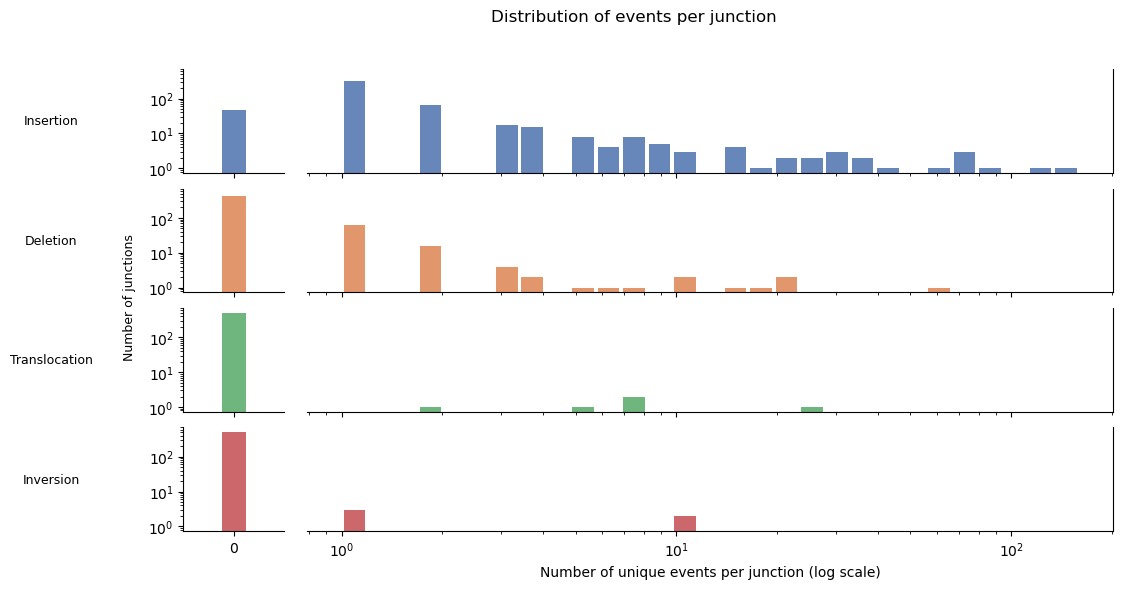

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2078: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



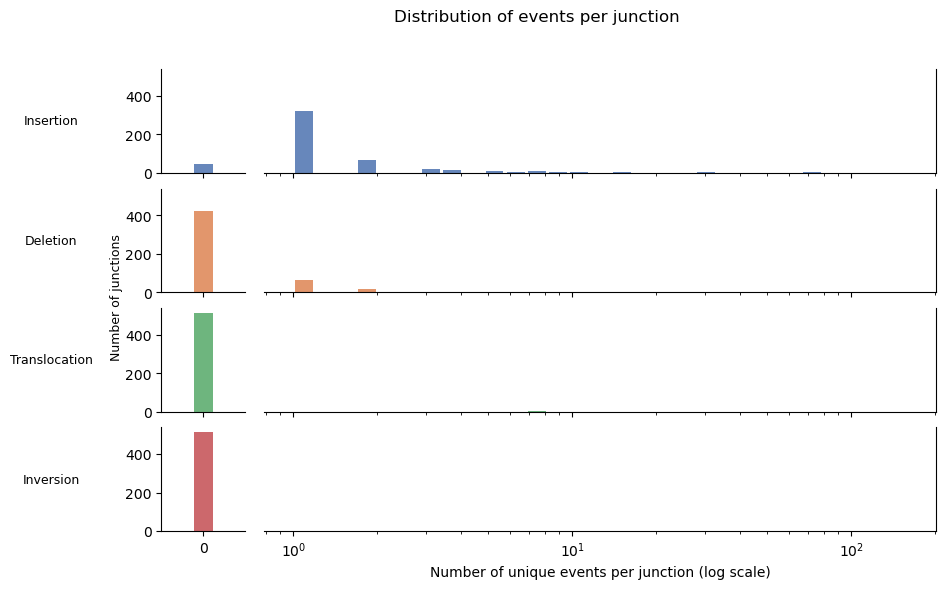

In [12]:
plot_event_counts_distribution(jdf_all, figsize=(12, 6), log_x = True, log_y = True, subplots = True)
plot_event_counts_distribution(jdf_all, figsize=(10, 6), log_x = True, log_y = False, subplots = True)

### Systematically analyze number of events for different clustering thresholds

In [15]:
summaries = combine_all_junctions_summaries(f"../results/atb_lookup", save_df=True)
deduplicated_events_df = deduplicate_events(summaries, save_path=f"../results/atb_lookup/deduplicated_events.csv")  
counts_df = count_events_per_junction(deduplicated_events_df, min_length=200, save_path=f"../results/atb_lookup/event_counts_per_junction.csv")

n_insertions, n_deletions, n_translocations, n_inversions, n_events = counts_df[['n_insertion', 'n_deletion', 'n_translocation', 'n_inversion', 'n_events']].sum()


Saved insertions summary to ../results/atb_lookup/insertions/all_junctions_insertions.csv
Saved deletions summary to ../results/atb_lookup/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup/deduplicated_events.csv
Saved event counts to ../results/atb_lookup/event_counts_per_junction.csv


In [6]:
all_results = []
tree_path = "../config/polished_tree.nwk"

for thresh in ['05', '1', '2', '3', '4', '5', '6']:
    cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_00{thresh}.csv")
    n_junctions_with_clusters = len(cluster_df[cluster_df['n_clusters']>1])
    n_additional_clusters = cluster_df.n_clusters.sum() - len(cluster_df)

    summaries = combine_all_junctions_summaries(f"../results/atb_lookup_000{thresh}", save_df=True)
    deduplicated_events_df = deduplicate_events(summaries, save_path=f"../results/atb_lookup_000{thresh}/deduplicated_events.csv")  
    counts_df = count_events_per_junction(deduplicated_events_df, min_length=200, save_path=f"../results/atb_lookup_000{thresh}/event_counts_per_junction.csv")

    n_insertions, n_deletions, n_translocations, n_inversions, n_events = counts_df[['n_insertion', 'n_deletion', 'n_translocation', 'n_inversion', 'n_events']].sum()

    per_cluster_parsimony_df = pd.read_csv(f"../results/consensus_analysis/parsimonious_clusters_000{thresh}.csv")
    multi_cluster_df = per_cluster_parsimony_df[per_cluster_parsimony_df["n_clusters"] > 1].copy()
    n_clusters_not_consistent = (multi_cluster_df["n_parsimony_steps"] > 1).sum()
    inconsistant_junctions = multi_cluster_df.loc[multi_cluster_df["n_parsimony_steps"] > 1, "junction_name"].nunique()
    n_clusters_in_multi_cluster_junctions = len(multi_cluster_df) # total number of clusters in junctions with > 1 cluster

    result_dict = {
        "threshold": f"0.00{thresh}",
        "n_junctions_with_clusters": n_junctions_with_clusters,
        "n_additional_clusters": n_additional_clusters,
        "n_insertions": n_insertions,
        "n_deletions": n_deletions,
        "n_translocations": n_translocations,
        "n_inversions": n_inversions,
        "n_events": n_events,
        "n_inconsistant_cluster": n_clusters_not_consistent,
        "n_inconsistant_junctions": inconsistant_junctions,
        "n_cluster_multicluster_junctions": n_clusters_in_multi_cluster_junctions, # different from n_additional clusters because it only considers some junctions instead of one cluster less per junction
    }

    all_results.append(result_dict)

results_df = pd.DataFrame(all_results)

    

Saved insertions summary to ../results/atb_lookup_00005/insertions/all_junctions_insertions.csv
Saved deletions summary to ../results/atb_lookup_00005/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup_00005/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup_00005/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup_00005/deduplicated_events.csv
Saved event counts to ../results/atb_lookup_00005/event_counts_per_junction.csv
Saved insertions summary to ../results/atb_lookup_0001/insertions/all_junctions_insertions.csv
Saved deletions summary to ../results/atb_lookup_0001/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup_0001/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup_0001/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup_0001/d

In [7]:
results_df

,threshold,n_junctions_with_clusters,n_additional_clusters,n_insertions,n_deletions,n_translocations,n_inversions,n_events,n_inconsistant_cluster,n_inconsistant_junctions,n_cluster_multicluster_junctions
0,0.0005,263,516,1778.0,285.0,23.0,25.0,2111.0,15,15,779
1,0.001,222,378,1765.0,287.0,49.0,25.0,2126.0,11,11,600
2,0.002,183,327,1780.0,291.0,52.0,26.0,2149.0,12,12,510
3,0.003,153,283,1801.0,306.0,56.0,27.0,2190.0,13,13,436
4,0.004,135,249,1814.0,302.0,55.0,25.0,2196.0,11,11,384
5,0.005,109,199,1806.0,302.0,51.0,25.0,2184.0,10,9,308
6,0.006,86,159,1811.0,308.0,51.0,25.0,2195.0,12,11,245


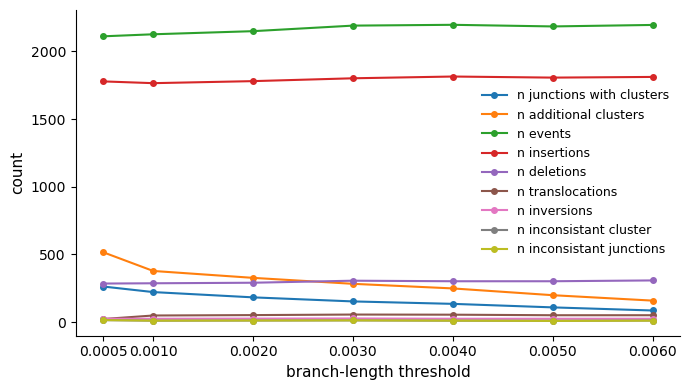

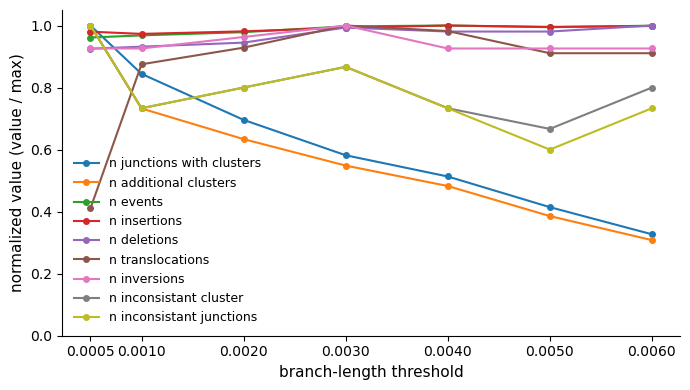

In [5]:
plot_clustering_threshold_sweep(results_df, figsize=(7,4), save_path=None, normalize=False)
plot_clustering_threshold_sweep(results_df, figsize=(7,4), save_path=None, normalize=True)

In [12]:
core_pairwise_paths = [f"../results/consensus_analysis/cluster_pairwise_dist_000{thresh}.csv" for thresh in [1,2,3,4,5,6]]
block_paths = [f"../results/consensus_analysis/cluster_block_ji_000{thresh}.csv" for thresh in [1,2,3,4,5,6]]
edge_paths = [f"../results/consensus_analysis/cluster_edge_ji_000{thresh}.csv" for thresh in [1,2,3,4,5,6]]

# maybe need to compare clustering between junctions that have clusters in all cases but more or less, this is done now
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_006.csv")
clustering_exists = cluster_df[cluster_df['n_clusters'] > 1].junction_name.to_list()

wb_core_pairwise_dfs = []
wb_block_dfs = []
wb_edge_dfs = []

for path in core_pairwise_paths:
    wb_diff_df = pd.read_csv(path)
    #wb_diff_df = wb_diff_df[wb_diff_df["n_clusters"] > 1]
    wb_diff_df = wb_diff_df[wb_diff_df["junction_name"].isin(clustering_exists)]
    wb_diff_df = add_silhouette_scores(wb_diff_df, within_col = 'mean_within_dist', between_col='mean_between_dist', is_similarity=False)
    wb_core_pairwise_dfs.append(wb_diff_df)

for path in block_paths:
    wb_diff_df = pd.read_csv(path)
    #wb_diff_df = wb_diff_df[wb_diff_df["n_clusters"] > 1]
    wb_diff_df = wb_diff_df[wb_diff_df["junction_name"].isin(clustering_exists)]
    wb_diff_df = add_silhouette_scores(wb_diff_df, within_col = 'mean_within_dist', between_col='mean_between_dist', is_similarity=True)
    wb_block_dfs.append(wb_diff_df)

for path in edge_paths:
    wb_diff_df = pd.read_csv(path)
    #wb_diff_df = wb_diff_df[wb_diff_df["n_clusters"] > 1]
    wb_diff_df = wb_diff_df[wb_diff_df["junction_name"].isin(clustering_exists)]
    wb_diff_df = add_silhouette_scores(wb_diff_df, within_col = 'mean_within_dist', between_col='mean_between_dist', is_similarity=True)
    wb_edge_dfs.append(wb_diff_df)

In [13]:
wb_block_dfs[0]

,junction_name,n_clusters,mean_between_dist,mean_within_dist,mean_within_dist_cl_0,mean_within_dist_cl_1,mean_within_dist_cl_2,mean_within_dist_cl_3,mean_within_dist_cl_4,mean_within_dist_cl_5,...,mean_between_dist_cl_3,mean_between_dist_cl_4,mean_between_dist_cl_5,mean_between_dist_cl_6,mean_between_dist_cl_7,mean_between_dist_cl_8,mean_between_dist_cl_9,mean_between_dist_cl_10,mean_between_dist_cl_11,silhouette_score
2,JNLRGIQXOF_f__YQUHGDANHE_f,3,0.998039,0.998028,0.996055,NaN,NaN,1.000000,NaN,NaN,...,0.998039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.005772
16,JPYVXRYZLU_f__UUBXUCAQCF_f,2,0.998039,0.998039,0.996078,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
23,ITEMFVYTUE_r__JVDYVQZUBR_r,7,0.955426,0.990000,1.000000,NaN,NaN,NaN,NaN,1.00000,...,0.506335,NaN,0.504091,0.506335,NaN,0.965849,NaN,0.989486,0.987637,0.775655
24,ITEMFVYTUE_f__PIVHURLJVP_f,5,0.955886,0.999365,0.998095,NaN,NaN,NaN,NaN,1.00000,...,0.996833,NaN,0.996818,0.499548,0.996729,NaN,NaN,NaN,NaN,0.985607
25,ISADOQMCVR_r__JKXDSPORHF_r,4,0.974146,1.000000,1.000000,NaN,NaN,NaN,NaN,1.00000,...,0.998869,0.75,0.998832,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,VZOKOXMBEZ_r__YUOECYBHUS_f,9,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.000000,NaN,1.000000,1.000000,NaN,NaN,1.000000,0.000000
516,EVCCMUBHOL_r__WNLYKTZGKW_f,3,0.594506,0.978207,0.956413,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.946255
531,CYGJWOEQKN_r__EOBHADSLFU_r,2,0.946667,0.954286,1.000000,0.908571,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.142857
532,XXVMWZCEKI_r__YUOECYBHUS_r,12,0.577263,0.826530,0.706484,0.832499,NaN,0.968354,NaN,NaN,...,0.719649,NaN,0.703851,0.603329,NaN,0.476460,NaN,0.172605,0.219514,0.589651
